# Theme 1


In [1]:
pip install colorama -q


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Rock Paper Scissors Classification

### package import

In [2]:
import os
import torch
import numpy as np
from PIL import Image
from tqdm import tqdm
import torch.nn as nn
import torch.optim as optim
from datetime import datetime
import matplotlib.pyplot as plt
import torch.nn.functional as F
from colorama import Fore, Style, init
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.transforms import InterpolationMode
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torchvision.models import resnet18, ResNet18_Weights,efficientnet_b0, EfficientNet_B0_Weights

### Hyperparameters

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Now Using {DEVICE}")

EPOCHS = 10
BATCH_SIZE = 32
LEARNING_RATE = 0.001
MOMENTUM = 0.9
ALPHA = 0.25
GAMMA = 2
PATIENCE = 5


Now Using cuda


### Data Loading

In [4]:
data_root = "./data/Rock-Paper-Scissors"

train_dir = os.path.join(data_root, "train")
val_dir = os.path.join(data_root, "validation")
test_dir = os.path.join(data_root, "test")

### Utility

In [5]:
def create_output_dir():
    out_dir = "./out/model"
    if not os.path.exists(out_dir):
        os.makedirs(out_dir)
    return out_dir

def write_log(message, log_path="./training.log"):
    with open(log_path, "a", encoding="utf-8") as f:
        f.write(message + "\n")

def plot_loss_acc(train_losses, val_losses, val_accs, save_path="./out/loss_acc_curve.png"):
    os.makedirs("./out", exist_ok=True)

    plt.figure(figsize=(12, 5))

    # Loss 曲線
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Val Loss")
    plt.title("Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy 曲線
    plt.subplot(1, 2, 2)
    plt.plot(val_accs, label="Val Accuracy")
    plt.title("Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()

    print(f"Saved training curves to: {save_path}")

def plot_confusion_matrix(model, data_loader, class_names, save_path="./out/confusion_matrix.png"):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    plt.figure(figsize=(6, 6))
    disp.plot(cmap="Blues", values_format="d")
    plt.title("Confusion Matrix")
    plt.savefig(save_path, dpi=200)
    plt.show()

    print(f"Saved confusion matrix to: {save_path}")

def evaluate_testset(model, test_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = correct / total
    print(f"Test Accuracy: {acc:.4f}")
    return acc


def predict_and_plot(model, img_path, class_names):
    model.eval()

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    img = Image.open(img_path).convert("RGB")
    input_tensor = transform(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = model(input_tensor)
        _, pred = torch.max(output, 1)

    pred_class = class_names[pred.item()]

    # 顯示圖片
    plt.imshow(img)
    plt.title(f"Prediction: {pred_class}")
    plt.axis("off")
    plt.show()

    return pred_class

### Data Augmentation

In [6]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


### Dataset & DataLoader

In [7]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

class_names = train_dataset.classes
print("Classes:", class_names)


Classes: ['paper', 'rock', 'scissors']


### Model A — ResNet18


In [8]:
model_resnet18 = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

model_resnet18.fc = nn.Linear(model_resnet18.fc.in_features, 3)
model_resnet18 = model_resnet18.to(DEVICE)

### Model B — EfficientNet-B0

In [9]:
model_effnet = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

model_effnet.classifier[1] = nn.Linear(model_effnet.classifier[1].in_features, 3)
model_effnet = model_effnet.to(DEVICE)

### Model C — 自建 CNN

In [10]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 28 * 28, 128)
        self.fc2 = nn.Linear(128, 3)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model_cnn = SimpleCNN().to(DEVICE)

### Training model

In [ ]:
def train_model(
    model,
    train_loader,
    val_loader,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    patience=5,
    save_prefix="model"
):

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2
    )

    log_path = "./out/training.log"
    write_log(f"====== Training Start ({datetime.now()}) ======", log_path)

    out_dir = create_output_dir()

    best_val_loss = float("inf")
    no_improve = 0

    train_losses, val_losses, val_accs = [], [], []

    for epoch in range(epochs):

        # ==================================================
        # TRAINING
        # ==================================================
        model.train()
        running_loss = 0.0

        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", colour="green")

        for images, labels in train_pbar:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            train_pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # ==================================================
        # VALIDATION
        # ==================================================
        model.eval()
        total = 0
        correct = 0
        val_loss_sum = 0.0

        val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", colour="cyan")

        with torch.no_grad():
            for images, labels in val_pbar:
                images, labels = images.to(DEVICE), labels.to(DEVICE)

                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss_sum += loss.item()

                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

                val_pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        avg_val_loss = val_loss_sum / len(val_loader)
        val_losses.append(avg_val_loss)

        val_acc = correct / total
        val_accs.append(val_acc)

        scheduler.step(avg_val_loss)

        # ==================================================
        # 彩色 Terminal 訊息
        # ==================================================
        msg = (
            f"{Fore.YELLOW}Epoch {epoch+1}/{epochs} | "
            f"{Fore.GREEN}Train Loss: {avg_train_loss:.4f} | "
            f"{Fore.CYAN}Val Loss: {avg_val_loss:.4f} | "
            f"{Fore.MAGENTA}Val Acc: {val_acc:.4f}{Style.RESET_ALL}"
        )
        print(msg)
        write_log(msg, log_path)

        # ==================================================
        # Save Best Model
        # ==================================================
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            no_improve = 0
            save_path = os.path.join(out_dir, f"{save_prefix}.pth")

            torch.save(model.state_dict(), save_path)
            print(Fore.GREEN + f"[Save] Best model saved: {save_path}")
            write_log(f"[Save] Best model saved: {save_path}", log_path)

        else:
            no_improve += 1
            print(Fore.RED + f"[No Improve] {no_improve}/{patience}")

            if no_improve >= patience:
                print(Fore.RED + "[Early Stop] No improvement, stopping training.")
                write_log("[Early Stop] Training stopped.", log_path)
                break

    write_log("====== Training End ======\n", log_path)

    return train_losses, val_losses, val_accs

### models training process


In [12]:
models_to_train = {
    "resnet18": model_resnet18,
    "effnet_b0": model_effnet,
    "simplecnn": model_cnn
}

results = {}

for name, model in models_to_train.items():

    print(f"\n\n===== Training {name} =====")

    # --- 重新設定 output 層 ---
    if name == "resnet18":
        model.fc = nn.Linear(model.fc.in_features, 3)

    elif name == "effnet_b0":
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 3)

    # --- 移動到 GPU ---
    model = model.to(DEVICE)

    # --- 訓練 ---
    train_losses, val_losses, val_accs = train_model(
        model,
        train_loader,
        val_loader,
        epochs=EPOCHS,
        lr=LEARNING_RATE,
        patience=PATIENCE,
        save_prefix=name   # 🔥 每個模型使用不同名稱
    )

    # --- 存放訓練結果 ---
    results[name] = {
        "model": model,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_accs": val_accs
    }




===== Training resnet18 =====


Epoch 1/10 [Val]: 100%|██████████| 2/2 [00:00<00:00,  8.23it/s, loss=0.0002]


Epoch 1/10 | Train Loss: 0.0787 | Val Loss: 0.2371 | Val Acc: 0.8485
[Save] Best model saved: ./out/model/resnet18.pth


Epoch 2/10 [Val]: 100%|██████████| 2/2 [00:00<00:00, 11.12it/s, loss=0.0019]


Epoch 2/10 | Train Loss: 0.0164 | Val Loss: 0.0107 | Val Acc: 1.0000
[Save] Best model saved: ./out/model/resnet18.pth


...

Epoch 5/10 | Train Loss: 0.0294 | Val Loss: 0.0853 | Val Acc: 0.9697
[No Improve] 3/5


Epoch 6/10 [Val]: 100%|██████████| 2/2 [00:00<00:00, 10.85it/s, loss=0.0000]


Epoch 6/10 | Train Loss: 0.0069 | Val Loss: 0.0743 | Val Acc: 0.9697
[No Improve] 4/5


Epoch 7/10 [Val]: 100%|██████████| 2/2 [00:00<00:00,  9.31it/s, loss=0.0010]

Epoch 7/10 | Train Loss: 0.0065 | Val Loss: 0.0744 | Val Acc: 0.9091
[No Improve] 5/5
[Early Stop] No improvement, stopping training.


### Test Accuracy

In [13]:
for name, r in results.items():
    print(f"\nTesting {name} ...")
    evaluate_testset(r["model"], test_loader)



Testing resnet18 ...
Test Accuracy: 1.0000

Testing effnet_b0 ...
Test Accuracy: 1.0000

Testing simplecnn ...
Test Accuracy: 0.8871


### Plot loss and accuracy curves


Plotting curves for resnet18...


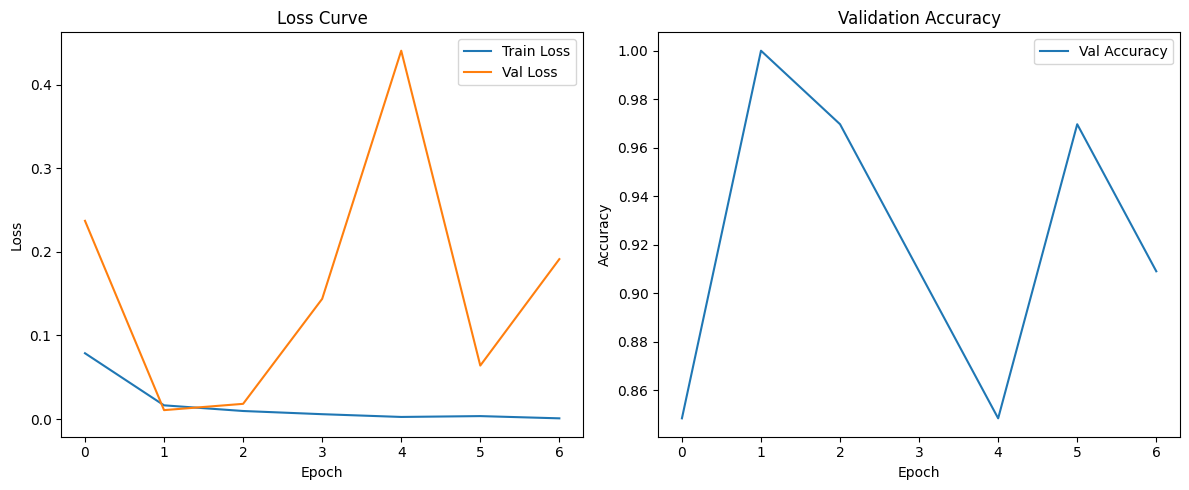

Saved training curves to: ./out/resnet18_curve.png

Plotting curves for effnet_b0...


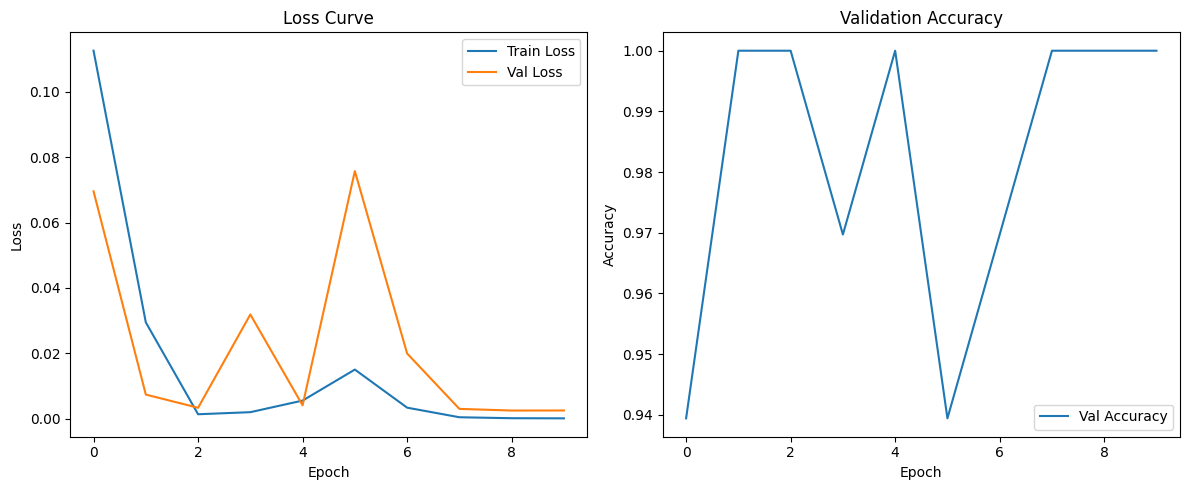

Saved training curves to: ./out/effnet_b0_curve.png

Plotting curves for simplecnn...


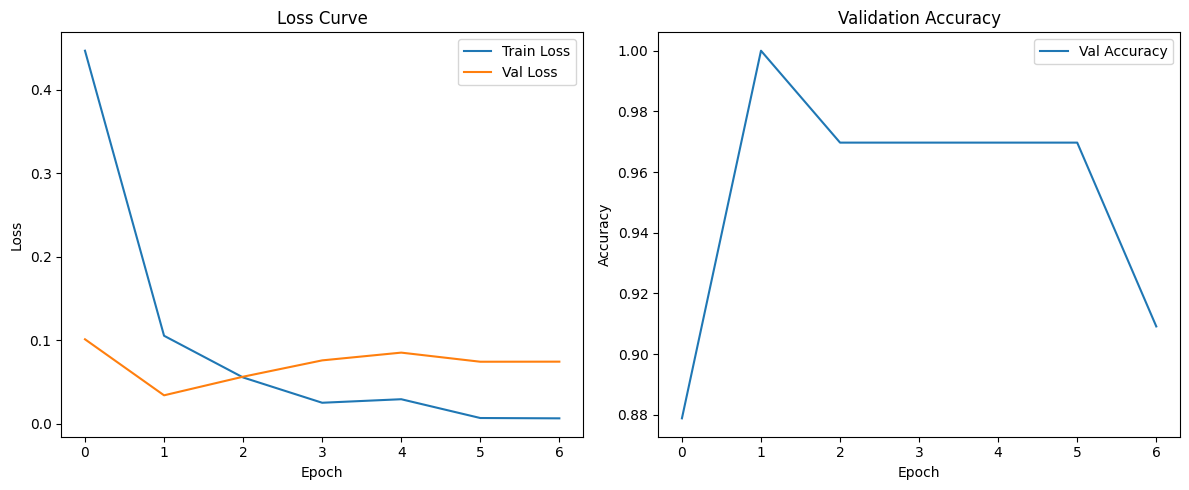

Saved training curves to: ./out/simplecnn_curve.png


In [14]:
for name, r in results.items():
    print(f"\nPlotting curves for {name}...")
    plot_loss_acc(
        r["train_losses"],
        r["val_losses"],
        r["val_accs"],
        save_path=f"./out/{name}_curve.png"
    )


### confusion matrix for each model


Confusion Matrix for resnet18 ...


<Figure size 600x600 with 0 Axes>

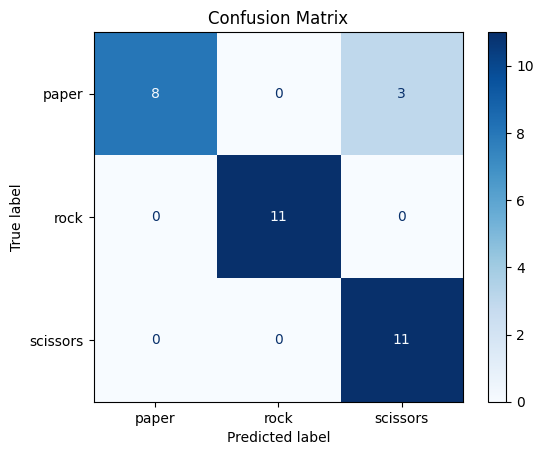

Saved confusion matrix to: ./out/resnet18_cm.png

Confusion Matrix for effnet_b0 ...


<Figure size 600x600 with 0 Axes>

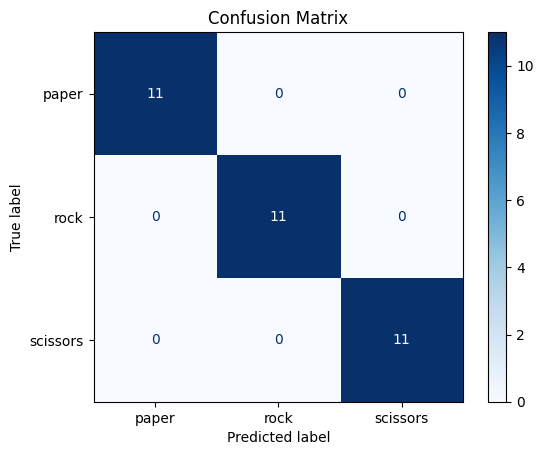

Saved confusion matrix to: ./out/effnet_b0_cm.png

Confusion Matrix for simplecnn ...


<Figure size 600x600 with 0 Axes>

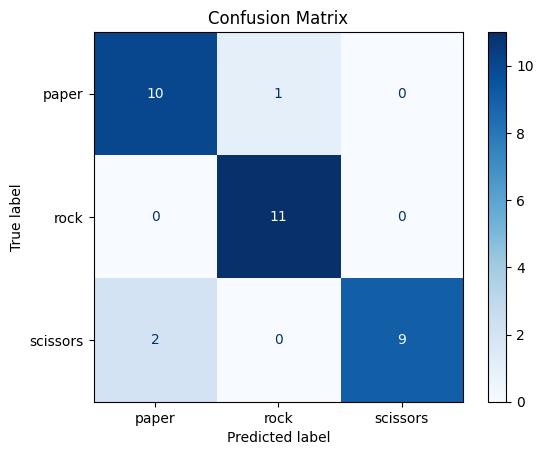

Saved confusion matrix to: ./out/simplecnn_cm.png


In [15]:
for name, r in results.items():
    print(f"\nConfusion Matrix for {name} ...")
    plot_confusion_matrix(
        r["model"], val_loader, class_names,
        save_path=f"./out/{name}_cm.png"
    )
